<div class="alert alert-block alert-info">

<h1 style="font-family:verdana;"> Descripción:</h1> 

<ul>
<li><p style="font-family:verdana;">
En este notebook, vamos a predecir si el ingreso de una persona es superior a 50k o inferior a 50k usando varias características como edad, educación y ocupación.
</p></li>
    
<li><p style="font-family:verdana;">
El conjunto de datos que vamos a usar es el dataset Adult del censo de ingresos de Kaggle que contiene aproximadamente 32561 filas y 15 características que se pueden descargar <a href="https://www.kaggle.com/uciml/adult-census-income">aquí</a>.
</p></li> 

<li><p style="font-family:verdana;">
El dataset contiene las etiquetas que tenemos que predecir y las etiquetas son discretas y binarias. Entonces, el problema que tenemos es de tipo Clasificación Supervisada.
</p></li>  
</ul>

</div>

## Paso 0: Cargar librerías y dataset

In [2]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Importar dataset
dataset = pd.read_csv('adult.csv')

## Paso 1: Análisis descriptivo

In [4]:
# Vista previa del dataset
dataset.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [5]:
# Forma del dataset
print('Filas: {} Columnas: {}'.format(dataset.shape[0], dataset.shape[1]))

Filas: 32561 Columnas: 15


In [6]:
# Tipo de datos de las características
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [7]:
# Resumen estadístico
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education.num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital.gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital.loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours.per.week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


In [8]:
# Verificar valores nulos
round((dataset.isnull().sum() / dataset.shape[0]) * 100, 2).astype(str) + ' %'

age               0.0 %
workclass         0.0 %
fnlwgt            0.0 %
education         0.0 %
education.num     0.0 %
marital.status    0.0 %
occupation        0.0 %
relationship      0.0 %
race              0.0 %
sex               0.0 %
capital.gain      0.0 %
capital.loss      0.0 %
hours.per.week    0.0 %
native.country    0.0 %
income            0.0 %
dtype: str

In [9]:
# Verificar '?' en dataset
round((dataset.isin(['?']).sum() / dataset.shape[0])
      * 100, 2).astype(str) + ' %'

age                0.0 %
workclass         5.64 %
fnlwgt             0.0 %
education          0.0 %
education.num      0.0 %
marital.status     0.0 %
occupation        5.66 %
relationship       0.0 %
race               0.0 %
sex                0.0 %
capital.gain       0.0 %
capital.loss       0.0 %
hours.per.week     0.0 %
native.country    1.79 %
income             0.0 %
dtype: str

In [10]:
# Contar las categorías de etiquetas
income = dataset['income'].value_counts(normalize=True)
round(income * 100, 2).astype('str') + ' %'

income
<=50K    75.92 %
>50K     24.08 %
Name: proportion, dtype: str

<div class="alert alert-block alert-info">

<h3 style="font-family:verdana;"> Observaciones:</h3>

<ul>
    
<li><p style="font-family:verdana;">
El dataset no tiene valores nulos, pero contiene valores faltantes en forma de '?' que necesitan ser preprocesados.
</p></li>    

<li><p style="font-family:verdana;">
El dataset está desbalanceado, ya que la característica dependiente 'income' contiene 75.92% de valores con ingreso menor a 50k y 24.08% de valores con ingreso mayor a 50k.
</p></li>    

</ul>

</div>

## Paso 3: Preprocesamiento de Datos

### 3.1: Corregir valores '?' en el dataset

In [ ]:
dataset = dataset.replace('?', np.nan)

In [ ]:
# Verificar valores nulos
round((dataset.isnull().sum() / dataset.shape[0]) * 100, 2).astype(str) + ' %'

age                0.0 %
workclass         5.64 %
fnlwgt             0.0 %
education          0.0 %
education.num      0.0 %
marital.status     0.0 %
occupation        5.66 %
relationship       0.0 %
race               0.0 %
sex                0.0 %
capital.gain       0.0 %
capital.loss       0.0 %
hours.per.week     0.0 %
native.country    1.79 %
income             0.0 %
dtype: object

In [ ]:
columns_with_nan = ['workclass', 'occupation', 'native.country']

In [ ]:
for col in columns_with_nan:
    dataset[col].fillna(dataset[col].mode()[0], inplace=True)

### 3.2: Codificación de Etiquetas

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
for col in dataset.columns:
    if dataset[col].dtypes == 'object':
        encoder = LabelEncoder()
        dataset[col] = encoder.fit_transform(dataset[col])

### 3.3: Selección de Características

In [ ]:
X = dataset.drop('income', axis=1)
Y = dataset['income']

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
selector = ExtraTreesClassifier(random_state=42)

In [ ]:
selector.fit(X, Y)

ExtraTreesClassifier(random_state=42)

In [ ]:
feature_imp = selector.feature_importances_

In [ ]:
for index, val in enumerate(feature_imp):
    print(index, round((val * 100), 2))

0 15.59
1 4.13
2 16.71
3 3.87
4 8.66
5 8.04
6 7.27
7 8.62
8 1.47
9 2.84
10 8.83
11 2.81
12 9.64
13 1.53


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  int32
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  int32
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  int32
 6   occupation      32561 non-null  int32
 7   relationship    32561 non-null  int32
 8   race            32561 non-null  int32
 9   sex             32561 non-null  int32
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  int32
dtypes: int32(8), int64(6)
memory usage: 2.5 MB


In [ ]:
X = X.drop(['workclass', 'education', 'race', 'sex',
            'capital.loss', 'native.country'], axis=1)

### 3.4: Escalado de Características

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
for col in X.columns:
    scaler = StandardScaler()
    X[col] = scaler.fit_transform(X[col].values.reshape(-1, 1))

### 3.5: Corregir dataset desbalanceado usando Oversampling

In [ ]:
round(Y.value_counts(normalize=True) * 100, 2).astype('str') + ' %'

0    75.92 %
1    24.08 %
Name: income, dtype: object

In [ ]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)

In [ ]:
ros.fit(X, Y)

RandomOverSampler(random_state=42)

In [ ]:
X_resampled, Y_resampled = ros.fit_resample(X, Y)

In [ ]:
round(Y_resampled.value_counts(normalize=True) * 100, 2).astype('str') + ' %'

1    50.0 %
0    50.0 %
Name: income, dtype: object

### 3.6: Crear división entrenamiento-prueba

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
    X_resampled, Y_resampled, test_size=0.2, random_state=42)

In [ ]:
print("Forma de X_train:", X_train.shape)
print("Forma de X_test:", X_test.shape)
print("Forma de Y_train:", Y_train.shape)
print("Forma de Y_test:", Y_test.shape)

X_train shape: (39552, 8)
X_test shape: (9888, 8)
Y_train shape: (39552,)
Y_test shape: (9888,)


## Paso 4: Modelado de Datos

### 4.1: Regresión Logística

In [ ]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(random_state=42)

In [ ]:
log_reg.fit(X_train, Y_train)

LogisticRegression(random_state=42)

In [ ]:
Y_pred_log_reg = log_reg.predict(X_test)

### 4.2: Clasificador KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

In [ ]:
knn.fit(X_train, Y_train)

KNeighborsClassifier()

In [ ]:
Y_pred_knn = knn.predict(X_test)

### 4.3: Clasificador de Vectores de Soporte

In [ ]:
from sklearn.svm import SVC
svc = SVC(random_state=42)

In [ ]:
svc.fit(X_train, Y_train)

SVC(random_state=42)

In [ ]:
Y_pred_svc = svc.predict(X_test)

### 4.4: Clasificador Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()

In [ ]:
nb.fit(X_train, Y_train)

GaussianNB()

In [ ]:
Y_pred_nb = nb.predict(X_test)

### 4.5: Clasificador de Árbol de Decisión

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dec_tree = DecisionTreeClassifier(random_state=42)

In [ ]:
dec_tree.fit(X_train, Y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
Y_pred_dec_tree = dec_tree.predict(X_test)

### 4.6: Clasificador Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
ran_for = RandomForestClassifier(random_state=42)

In [ ]:
ran_for.fit(X_train, Y_train)

RandomForestClassifier(random_state=42)

In [ ]:
Y_pred_ran_for = ran_for.predict(X_test)

### 4.7: Clasificador XGB

In [ ]:
from xgboost import XGBClassifier
xgb = XGBClassifier()

In [ ]:
xgb.fit(X_train, Y_train)

XGBClassifier(base_score=0.5, booster=None, colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, gamma=0, gpu_id=-1,
              importance_type='gain', interaction_constraints=None,
              learning_rate=0.300000012, max_delta_step=0, max_depth=6,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              n_estimators=100, n_jobs=0, num_parallel_tree=1, random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
              tree_method=None, validate_parameters=False, verbosity=None)

In [ ]:
Y_pred_xgb = xgb.predict(X_test)

## Paso 5: Evaluación del Modelo

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

In [ ]:
print('Regresión Logística:')
print('Puntuación de precisión:', round(accuracy_score(Y_test, Y_pred_log_reg) * 100, 2))
print('Puntuación F1:', round(f1_score(Y_test, Y_pred_log_reg) * 100, 2))

Logistic Regression:
Accuracy score: 75.25
F1 score: 75.08


In [ ]:
print('Clasificador KNN:')
print('Puntuación de precisión:', round(accuracy_score(Y_test, Y_pred_knn) * 100, 2))
print('Puntuación F1:', round(f1_score(Y_test, Y_pred_knn) * 100, 2))

KNN Classifier:
Accuracy score: 83.42
F1 score: 84.43


In [ ]:
print('Clasificador de Vectores de Soporte:')
print('Puntuación de precisión:', round(accuracy_score(Y_test, Y_pred_svc) * 100, 2))
print('Puntuación F1:', round(f1_score(Y_test, Y_pred_svc) * 100, 2))

Support Vector Classifier:
Accuracy score: 81.58
F1 score: 82.56


In [ ]:
print('Clasificador Naive Bayes:')
print('Puntuación de precisión:', round(accuracy_score(Y_test, Y_pred_nb) * 100, 2))
print('Puntuación F1:', round(f1_score(Y_test, Y_pred_nb) * 100, 2))

Naive Bayes Classifier:
Accuracy score: 64.68
F1 score: 48.42


In [ ]:
print('Clasificador de Árbol de Decisión:')
print('Puntuación de precisión:', round(accuracy_score(Y_test, Y_pred_dec_tree) * 100, 2))
print('Puntuación F1:', round(f1_score(Y_test, Y_pred_dec_tree) * 100, 2))

Decision Tree Classifier:
Accuracy score: 91.61
F1 score: 92.01


In [ ]:
print('Clasificador Random Forest:')
print('Puntuación de precisión:', round(accuracy_score(Y_test, Y_pred_ran_for) * 100, 2))
print('Puntuación F1:', round(f1_score(Y_test, Y_pred_ran_for) * 100, 2))

Random Forest Classifier:
Accuracy score: 92.6
F1 score: 92.93


In [ ]:
print('Clasificador XGB:')
print('Puntuación de precisión:', round(accuracy_score(Y_test, Y_pred_xgb) * 100, 2))
print('Puntuación F1:', round(f1_score(Y_test, Y_pred_xgb) * 100, 2))

XGB Classifier:
Accuracy score: 86.09
F1 score: 86.57


## Paso 6: Ajuste de Hiperparámetros

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
n_estimators = [int(x) for x in np.linspace(start=40, stop=150, num=15)]
max_depth = [int(x) for x in np.linspace(40, 150, num=15)]

In [ ]:
param_dist = {
    'n_estimators': n_estimators,
    'max_depth': max_depth,
}

In [ ]:
rf_tuned = RandomForestClassifier(random_state=42)

In [ ]:
rf_cv = RandomizedSearchCV(
    estimator=rf_tuned, param_distributions=param_dist, cv=5, random_state=42)

In [ ]:
rf_cv.fit(X_train, Y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   param_distributions={'max_depth': [40, 47, 55, 63, 71, 79,
                                                      87, 95, 102, 110, 118,
                                                      126, 134, 142, 150],
                                        'n_estimators': [40, 47, 55, 63, 71, 79,
                                                         87, 95, 102, 110, 118,
                                                         126, 134, 142, 150]},
                   random_state=42)

In [ ]:
rf_cv.best_score_

0.9131271105332539

In [ ]:
rf_cv.best_params_

{'n_estimators': 40, 'max_depth': 102}

In [ ]:
rf_best = RandomForestClassifier(
    max_depth=102, n_estimators=40, random_state=42)

In [ ]:
rf_best.fit(X_train, Y_train)

RandomForestClassifier(max_depth=102, n_estimators=40, random_state=42)

In [ ]:
Y_pred_rf_best = rf_best.predict(X_test)

In [ ]:
print('Clasificador Random Forest:')
print('Puntuación de precisión:', round(accuracy_score(Y_test, Y_pred_rf_best) * 100, 2))
print('Puntuación F1:', round(f1_score(Y_test, Y_pred_rf_best) * 100, 2))

Random Forest Classifier:
Accuracy score: 92.77
F1 score: 93.08


In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, Y_pred_rf_best)

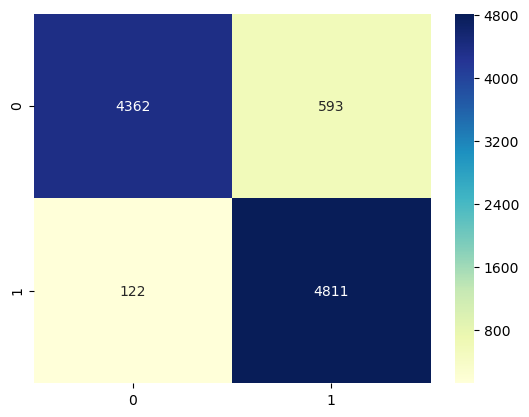

In [ ]:
plt.style.use('default')
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
plt.savefig('heatmap.png')
plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(Y_test, Y_pred_rf_best))

              precision    recall  f1-score   support

           0       0.97      0.88      0.92      4955
           1       0.89      0.98      0.93      4933

    accuracy                           0.93      9888
   macro avg       0.93      0.93      0.93      9888
weighted avg       0.93      0.93      0.93      9888



<div class="alert alert-block alert-info">

<h3 style="font-family:verdana;"> Conclusión:</h3>

<ul>
    
<li><p style="font-family:verdana;">
En este proyecto, construimos varios modelos como regresión logística, clasificador knn, clasificador de vectores de soporte, clasificador de árbol de decisión, clasificador random forest y clasificador xgboost.
</p></li>    

<li><p style="font-family:verdana;">
Un clasificador random forest ajustado por hiperparámetros da la puntuación de precisión más alta de 92.77 y una puntuación f1 de 93.08.
</p></li>    

</ul>

</div>

<div class="alert alert-block alert-info">

<h3 style="font-family:verdana;"> Trabajo Futuro:</h3>

<ul>
        
<li><p style="font-family:verdana;">
Tenemos un dataset lo suficientemente grande, por lo que podemos usar redes neuronales como una red neuronal artificial para construir un modelo que pueda resultar en un mejor desempeño.
</p></li>    

</ul>

</div>

## Extra: Modelo multivariable + métricas de clasificación
En esta sección usamos **todas las variables** del dataset (`modelo multivariable`) y calculamos las métricas principales: `accuracy`, matriz de confusión, `precision`, `recall`, `f1` y `roc_auc`.

In [ ]:
# 1) Preparar datos para clasificación binaria multivariable
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

df = dataset.copy()

# Estandarizamos cadenas para evitar problemas con espacios
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

# En Adult, '?' representa dato faltante
df = df.replace("?", np.nan)

target_col = "income"
X = df.drop(columns=[target_col])

# Etiqueta binaria: 1 si ingreso >50K, 0 en caso contrario
y = df[target_col].str.contains(r">50K", regex=True).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Distribución y_train:", y_train.value_counts(normalize=True).round(3).to_dict())

In [ ]:
# 2) Pipeline multivariable: imputación + codificación + escalado + regresión logística
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

num_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_features = X_train.select_dtypes(include=["object"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

model.fit(X_train, y_train)

In [ ]:
# 3) Métricas: accuracy, precision, recall, f1, roc_auc y matriz de confusión
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

metricas = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
}

print(pd.Series(metricas).round(4))
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["<=50K", ">50K"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión - Modelo Multivariable")
plt.show()